# Statistical Hypothesis Analysis

This notebook tests several business hypotheses using Olist e-commerce data.

The main goals are:
- to determine whether observed differences are statistically significant;
- to estimate the magnitude of the effects;
- to distinguish statistical significance from practical business importance;
- to formulate data-driven business recommendations.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import stats

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from etl.config import get_engine

engine = get_engine()

pd.set_option("display.max_columns", 100)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.3f}",
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

pd.read_sql(
    "SELECT current_database() AS database_name;",
    engine,
)

,database_name
0,olist_analytics


## 1. Delivery Delays and Review Scores

### Hypothesis

We test whether delayed delivery is associated with lower customer review scores.

- **Null hypothesis \(H_0\):** review score distributions are the same for delayed and on-time orders.
- **Alternative hypothesis \(H_1\):** delayed orders receive lower review scores than on-time orders.

Only delivered orders with a recorded review score and known delivery status are included.

In [2]:
query = """
SELECT
    m.order_id,
    m.average_review_score AS review_score,
    m.is_delayed,
    m.delivery_time_days,
    m.delivery_delay_days
FROM analytics.order_metrics AS m
WHERE m.order_status = 'delivered'
  AND m.average_review_score IS NOT NULL
  AND m.is_delayed IS NOT NULL;
"""

delivery_reviews = pd.read_sql(query, engine)

delivery_reviews.head()

,order_id,review_score,is_delayed,delivery_time_days,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,4.000,False,8.437,-7.107
1,53cdb2fc8bc7dce0b6741e2150273451,4.000,False,13.782,-5.356
2,949d5b44dbf5de918fe9c16f97b45f8a,5.000,False,13.209,-12.980
3,ad21c59c0840e6cb83a9ceb5573f8159,5.000,False,2.874,-9.238
4,6514b8ad8028c9f2cc2374ded245783f,5.000,False,9.990,-11.461


In [3]:
delivery_reviews.shape

(95824, 5)

In [4]:
delivery_reviews.isna().sum()

order_id               0
review_score           0
is_delayed             0
delivery_time_days     0
delivery_delay_days    0
dtype: int64

In [6]:
on_time_reviews = delivery_reviews.loc[
    delivery_reviews["is_delayed"] == False,
    "review_score",
]

delayed_reviews = delivery_reviews.loc[
    delivery_reviews["is_delayed"] == True,
    "review_score",
]

group_sizes = pd.DataFrame(
    {
        "delivery_status": [
            "On Time",
            "Delayed",
        ],
        "orders_count": [
            len(on_time_reviews),
            len(delayed_reviews),
        ],
    }
)

group_sizes

,delivery_status,orders_count
0,On Time,88163
1,Delayed,7661


In [7]:
review_summary = (
    delivery_reviews
    .assign(
        delivery_status=np.where(
            delivery_reviews["is_delayed"],
            "Delayed",
            "On Time",
        )
    )
    .groupby("delivery_status")
    .agg(
        orders_count=("review_score", "count"),
        average_review_score=("review_score", "mean"),
        median_review_score=("review_score", "median"),
        standard_deviation=("review_score", "std"),
        low_score_share=(
            "review_score",
            lambda values: (values <= 2).mean(),
        ),
    )
    .reset_index()
)

review_summary["low_score_share_percent"] = (
    review_summary["low_score_share"] * 100
)

review_summary

,delivery_status,orders_count,average_review_score,median_review_score,standard_deviation,low_score_share,low_score_share_percent
0,Delayed,7661,2.567,2.000,1.658,0.540,53.988
1,On Time,88163,4.294,5.000,1.146,0.092,9.188


In [8]:
delivery_reviews_plot = delivery_reviews.copy()

delivery_reviews_plot["delivery_status"] = np.where(
    delivery_reviews_plot["is_delayed"],
    "Delayed",
    "On Time",
)

review_distribution = (
    delivery_reviews_plot
    .groupby(
        [
            "delivery_status",
            "review_score",
        ]
    )
    .size()
    .reset_index(name="reviews_count")
)

review_distribution["share_percent"] = (
    review_distribution["reviews_count"]
    / review_distribution.groupby(
        "delivery_status"
    )["reviews_count"].transform("sum")
    * 100
)

review_distribution

,delivery_status,review_score,reviews_count,share_percent
0,Delayed,1.000,3533,46.117
1,Delayed,1.500,1,0.013
2,Delayed,2.000,602,7.858
3,Delayed,2.500,6,0.078
4,Delayed,3.000,868,11.330
5,Delayed,3.500,3,0.039
6,Delayed,4.000,945,12.335
7,Delayed,4.500,2,0.026
8,Delayed,5.000,1701,22.203
9,On Time,1.000,5779,6.555


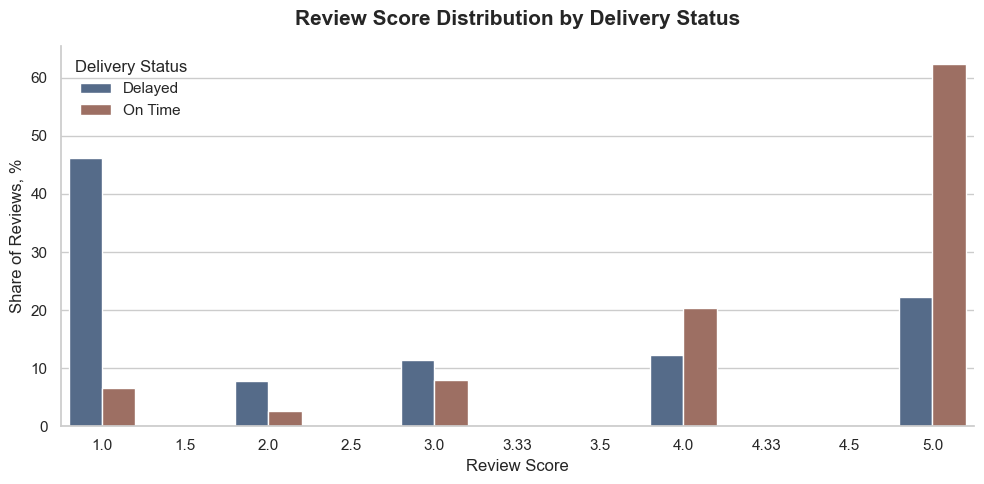

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=review_distribution,
    x="review_score",
    y="share_percent",
    hue="delivery_status",
    palette=[
        "#4C6A92",
        "#A66A5A",
    ],
    ax=ax,
)

ax.set_title(
    "Review Score Distribution by Delivery Status",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Review Score")
ax.set_ylabel("Share of Reviews, %")

ax.legend(
    title="Delivery Status",
    frameon=False,
)

sns.despine()
plt.tight_layout()
plt.show()

### Review distribution findings

The review score distributions differ substantially between delayed and on-time deliveries.

Delayed orders receive a score of 1 far more often, while on-time deliveries are much more likely to receive the maximum score of 5. The difference is not limited to the average score: the entire distribution shifts toward lower ratings for delayed orders.

This provides strong descriptive evidence that delivery delays are associated with lower customer satisfaction. The next step is to test whether this difference is statistically significant and to estimate the magnitude of the effect.

### Welch t-test

In [10]:
welch_result = stats.ttest_ind(
    delayed_reviews,
    on_time_reviews,
    equal_var=False,
    alternative="less",
)

welch_result

TtestResult(statistic=np.float64(-89.38438574379714), pvalue=np.float64(0.0), df=np.float64(8308.139803630824))

In [11]:
welch_statistic = welch_result.statistic
welch_p_value = welch_result.pvalue

welch_statistic, welch_p_value

(np.float64(-89.38438574379714), np.float64(0.0))

### Mann–Whitney U test

In [12]:
mann_whitney_result = stats.mannwhitneyu(
    delayed_reviews,
    on_time_reviews,
    alternative="less",
)

mann_whitney_result

MannwhitneyuResult(statistic=np.float64(150680825.5), pvalue=np.float64(0.0))

In [13]:
mann_whitney_statistic = mann_whitney_result.statistic
mann_whitney_p_value = mann_whitney_result.pvalue

mann_whitney_statistic, mann_whitney_p_value

(np.float64(150680825.5), np.float64(0.0))

### Effect Size: Cohen's d

In [14]:
def cohens_d(
    group_1: pd.Series,
    group_2: pd.Series,
) -> float:
    n_1 = len(group_1)
    n_2 = len(group_2)

    variance_1 = group_1.var(ddof=1)
    variance_2 = group_2.var(ddof=1)

    pooled_standard_deviation = np.sqrt(
        (
            (n_1 - 1) * variance_1
            + (n_2 - 1) * variance_2
        )
        / (n_1 + n_2 - 2)
    )

    return (
        group_1.mean() - group_2.mean()
    ) / pooled_standard_deviation

In [15]:
review_cohens_d = cohens_d(
    delayed_reviews,
    on_time_reviews,
)

review_cohens_d

np.float64(-1.4458113048698005)

### Effect Size Interpretation

Cohen's \(d\) measures the standardized difference between the average review scores of delayed and on-time orders.

Because the delayed group is passed first, a negative value means that delayed orders have lower review scores.

A common interpretation of the absolute value is:

- around 0.2 — small effect;
- around 0.5 — medium effect;
- around 0.8 or higher — large effect.

The calculated Cohen's \(d\) is -1.45, indicating a **large** effect. The negative sign confirms that delayed orders receive lower review scores than on-time orders.

### Statistical Test Summary

In [16]:
delay_review_test_summary = pd.DataFrame(
    {
        "metric": [
            "Delayed mean",
            "On-time mean",
            "Mean difference",
            "Welch p-value",
            "Mann–Whitney p-value",
            "Cohen's d",
        ],
        "value": [
            delayed_reviews.mean(),
            on_time_reviews.mean(),
            delayed_reviews.mean()
            - on_time_reviews.mean(),
            welch_p_value,
            mann_whitney_p_value,
            review_cohens_d,
        ],
    }
)

delay_review_test_summary

,metric,value
0,Delayed mean,2.567
1,On-time mean,4.294
2,Mean difference,-1.728
3,Welch p-value,0.000
4,Mann–Whitney p-value,0.000
5,Cohen's d,-1.446


### Hypothesis Test Conclusion

Both the Welch t-test and the Mann–Whitney U test produce p-values below the chosen significance level of \(0.05\). Therefore, the null hypothesis is rejected.

Delayed deliveries are associated with significantly lower review scores than on-time deliveries.

The conclusion is supported by:

- a lower average score for delayed orders;
- a visible shift toward low ratings in the score distribution;
- statistically significant results from both tests;
- a non-negligible standardized effect measured by Cohen's \(d\).

From a business perspective, reducing delivery delays is likely to improve customer satisfaction. However, the analysis establishes an association and does not prove that delivery delay is the only cause of lower ratings.

## 2. Order Value and Delivery Time

### Hypothesis

We test whether higher-value orders tend to have longer delivery times.

- **Null hypothesis \(H_0\):** order value and delivery time are not associated.
- **Alternative hypothesis \(H_1\):** higher order value is associated with longer delivery time.

Only delivered orders with known delivery time and order value are included.

### Data Preparation

In [17]:
query = """
SELECT
    order_id,
    order_items_value AS order_value,
    delivery_time_days
FROM analytics.order_metrics
WHERE order_status = 'delivered'
  AND order_items_value IS NOT NULL
  AND delivery_time_days IS NOT NULL;
"""

order_delivery = pd.read_sql(query, engine)

order_delivery.head()

,order_id,order_value,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,38.710,8.437
1,53cdb2fc8bc7dce0b6741e2150273451,141.460,13.782
2,949d5b44dbf5de918fe9c16f97b45f8a,72.200,13.209
3,ad21c59c0840e6cb83a9ceb5573f8159,28.620,2.874
4,6514b8ad8028c9f2cc2374ded245783f,75.160,9.990


In [18]:
order_delivery.shape

(96470, 3)

In [19]:
order_delivery.isna().sum()

order_id              0
order_value           0
delivery_time_days    0
dtype: int64

### Descriptive Statistics

In [20]:
order_delivery[
    [
        "order_value",
        "delivery_time_days",
    ]
].describe(
    percentiles=[
        0.5,
        0.75,
        0.9,
        0.95,
        0.99,
    ]
)

,order_value,delivery_time_days
count,"96,470.000","96,470.000"
mean,159.826,12.558
std,218.802,9.546
min,9.590,0.533
50%,105.280,10.217
75%,176.260,15.720
90%,305.906,23.096
95%,446.264,29.274
99%,"1,052.400",46.050
max,"13,664.080",209.629


In [21]:
order_value_99 = order_delivery["order_value"].quantile(0.99)
delivery_time_99 = order_delivery["delivery_time_days"].quantile(0.99)

order_value_99, delivery_time_99

(np.float64(1052.4002999999996), np.float64(46.05026180555554))

In [22]:
order_delivery_plot = order_delivery.loc[
    (order_delivery["order_value"] <= order_value_99)
    & (
        order_delivery["delivery_time_days"]
        <= delivery_time_99
    )
].copy()

### Relationship between Order Value and Delivery Time

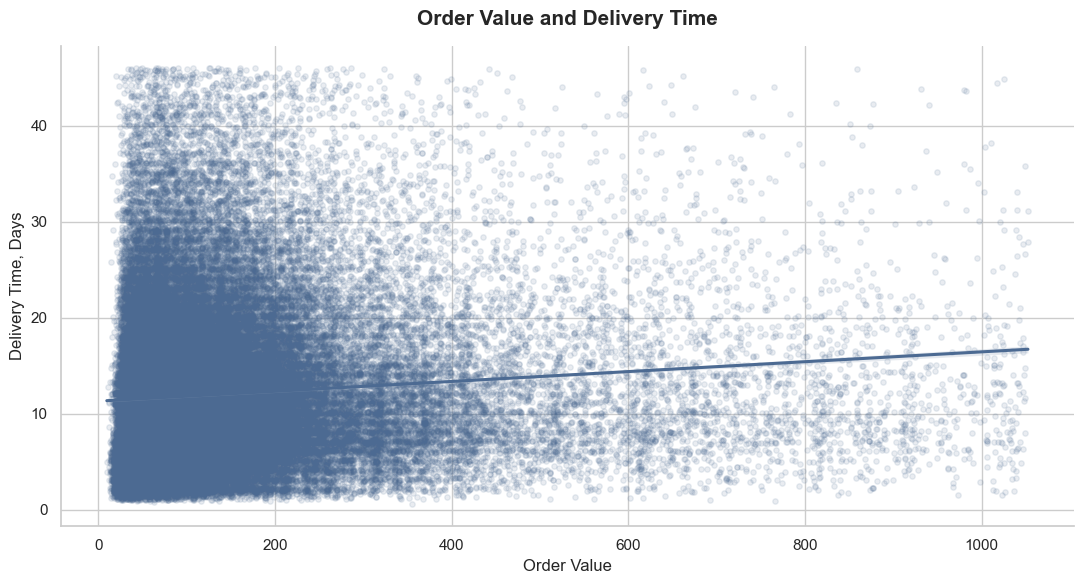

In [23]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.regplot(
    data=order_delivery_plot,
    x="order_value",
    y="delivery_time_days",
    scatter_kws={
        "alpha": 0.12,
        "s": 15,
    },
    line_kws={
        "linewidth": 2.2,
    },
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Order Value and Delivery Time",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Order Value")
ax.set_ylabel("Delivery Time, Days")

sns.despine()
plt.tight_layout()
plt.show()

### Relationship Findings

The scatter plot shows a weak positive relationship between order value and delivery time.

Higher-value orders appear to take slightly longer to deliver on average, as indicated by the upward-sloping trend line. However, the observations are widely dispersed around the line, so order value alone explains only a small part of the variation in delivery time.

The visual evidence therefore suggests a possible association, but its strength must be evaluated using correlation coefficients.

### Correlation Analysis

In [24]:
pearson_result = stats.pearsonr(
    order_delivery["order_value"],
    order_delivery["delivery_time_days"],
)

spearman_result = stats.spearmanr(
    order_delivery["order_value"],
    order_delivery["delivery_time_days"],
)

### Pearson Correlation

In [25]:
pearson_correlation = pearson_result.statistic
pearson_p_value = pearson_result.pvalue

pearson_correlation, pearson_p_value

(np.float64(0.06960233064733545), np.float64(6.894418515924152e-104))

### Spearman Correlation

In [26]:
spearman_correlation = spearman_result.statistic
spearman_p_value = spearman_result.pvalue

spearman_correlation, spearman_p_value

(np.float64(0.14255709497107086), np.float64(0.0))

### Correlation Summary

In [27]:
correlation_summary = pd.DataFrame(
    {
        "method": [
            "Pearson",
            "Spearman",
        ],
        "correlation": [
            pearson_correlation,
            spearman_correlation,
        ],
        "p_value": [
            pearson_p_value,
            spearman_p_value,
        ],
    }
)

correlation_summary

,method,correlation,p_value
0,Pearson,0.070,0.000
1,Spearman,0.143,0.000


### Correlation Findings

Both correlation coefficients are positive and statistically significant.

Pearson correlation is approximately 0.07, which indicates a negligible linear relationship between order value and delivery time. Spearman correlation is slightly higher at approximately 0.14, indicating a weak positive monotonic relationship.

The p-values are effectively equal to zero because of the large sample size, so the null hypothesis of no association is rejected. However, the effect itself is weak.

Therefore, higher-value orders tend to take slightly longer to deliver, but order value has limited practical importance as a standalone predictor of delivery time. Other factors, such as customer location, seller location, product category, freight conditions, and logistics infrastructure, are likely to explain much more of the variation.

## 3. Order Size and Freight Cost

### Hypothesis

We test whether orders containing more items have higher freight costs.

- **Null hypothesis \(H_0\):** the number of items in an order is not associated with freight cost.
- **Alternative hypothesis \(H_1\):** orders containing more items have higher freight costs.

Only delivered orders with known item count and freight value are included.

### Data Preparation

In [28]:
query = """
SELECT
    order_id,
    items_count,
    freight_value
FROM analytics.order_metrics
WHERE order_status = 'delivered'
  AND items_count IS NOT NULL
  AND freight_value IS NOT NULL;
"""

order_freight = pd.read_sql(query, engine)

order_freight.head()

,order_id,items_count,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,13.290
1,00018f77f2f0320c557190d7a144bdd3,1,19.930
2,000229ec398224ef6ca0657da4fc703e,1,17.870
3,00024acbcdf0a6daa1e931b038114c75,1,12.790
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,18.140


In [29]:
order_freight.shape

(96478, 3)

In [30]:
order_freight.isna().sum()

order_id         0
items_count      0
freight_value    0
dtype: int64

### Descriptive Statistics

In [31]:
order_freight[
    [
        "items_count",
        "freight_value",
    ]
].describe(
    percentiles=[
        0.5,
        0.75,
        0.9,
        0.95,
        0.99,
    ]
)

,items_count,freight_value
count,"96,478.000","96,478.000"
mean,1.142,22.785
std,0.539,21.559
min,1.000,0.000
50%,1.000,17.170
75%,1.000,24.017
90%,1.000,39.380
95%,2.000,54.780
99%,3.000,104.245
max,21.000,"1,794.960"


In [32]:
order_freight["items_group"] = pd.cut(
    order_freight["items_count"],
    bins=[0, 1, 2, 3, 4, float("inf")],
    labels=[
        "1 item",
        "2 items",
        "3 items",
        "4 items",
        "5+ items",
    ],
)

In [33]:
freight_by_items = (
    order_freight
    .groupby(
        "items_group",
        observed=False,
    )
    .agg(
        orders_count=("order_id", "count"),
        average_freight_value=("freight_value", "mean"),
        median_freight_value=("freight_value", "median"),
    )
    .reset_index()
)

freight_by_items

,items_group,orders_count,average_freight_value,median_freight_value
0,1 item,86843,20.328,16.460
1,2 items,7392,37.080,31.580
2,3 items,1306,54.802,47.520
3,4 items,495,74.144,63.160
4,5+ items,442,114.297,89.140


### Freight Cost by Number of Items

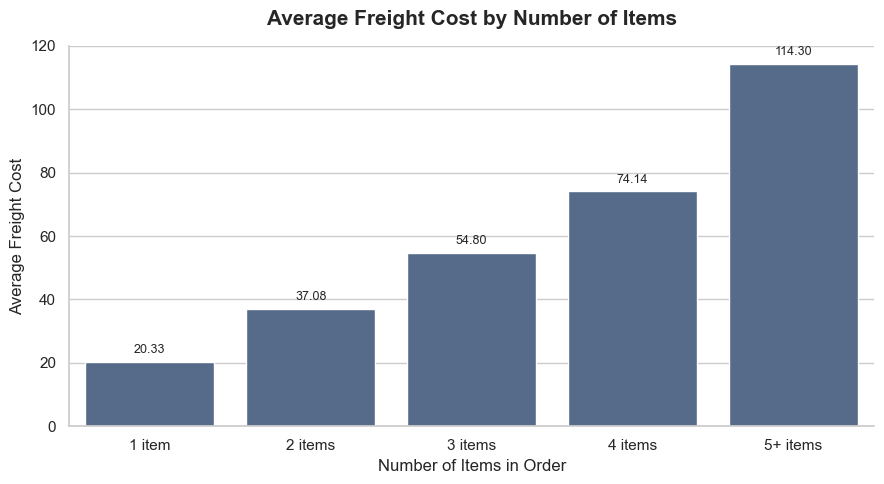

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=freight_by_items,
    x="items_group",
    y="average_freight_value",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Average Freight Cost by Number of Items",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Number of Items in Order")
ax.set_ylabel("Average Freight Cost")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=4,
        fontsize=9,
    )

sns.despine()
plt.tight_layout()
plt.show()

### Freight cost findings

Average freight cost increases consistently with the number of items in an order.

Orders containing one item have an average freight cost of approximately 20.33, compared with 37.08 for two-item orders and 54.80 for three-item orders. Orders containing five or more items have the highest average freight cost at approximately 114.30.

The pattern is monotonic and economically meaningful: larger baskets generally require more expensive transportation. However, item count is not the only factor affecting freight cost. Product weight and dimensions, seller location, customer location, and delivery distance may also contribute.

### Spearman Correlation

In [35]:
freight_spearman_result = stats.spearmanr(
    order_freight["items_count"],
    order_freight["freight_value"],
)

freight_spearman_correlation = (
    freight_spearman_result.statistic
)

freight_spearman_p_value = (
    freight_spearman_result.pvalue
)

freight_spearman_correlation, freight_spearman_p_value

(np.float64(0.3782838363736563), np.float64(0.0))

### Kruskal–Wallis Test

In [36]:
freight_groups = [
    group["freight_value"].values
    for _, group in order_freight.groupby(
        "items_group",
        observed=False,
    )
]

kruskal_result = stats.kruskal(
    *freight_groups
)

kruskal_statistic = kruskal_result.statistic
kruskal_p_value = kruskal_result.pvalue

kruskal_statistic, kruskal_p_value

(np.float64(13971.834288948208), np.float64(0.0))

### Effect Size: Epsilon-Squared

In [37]:
number_of_groups = (
    order_freight["items_group"]
    .nunique()
)

number_of_observations = len(order_freight)

epsilon_squared = (
    kruskal_statistic
    - number_of_groups
    + 1
) / (
    number_of_observations
    - number_of_groups
)

epsilon_squared

np.float64(0.14478490654326298)

### Statistical Test Summary

In [38]:
freight_test_summary = pd.DataFrame(
    {
        "metric": [
            "Spearman correlation",
            "Spearman p-value",
            "Kruskal–Wallis statistic",
            "Kruskal–Wallis p-value",
            "Epsilon-squared",
        ],
        "value": [
            freight_spearman_correlation,
            freight_spearman_p_value,
            kruskal_statistic,
            kruskal_p_value,
            epsilon_squared,
        ],
    }
)

freight_test_summary

,metric,value
0,Spearman correlation,0.378
1,Spearman p-value,0.000
2,Kruskal–Wallis statistic,"13,971.834"
3,Kruskal–Wallis p-value,0.000
4,Epsilon-squared,0.145


### Hypothesis Test Conclusion

The relationship between the number of items in an order and freight cost is statistically significant and practically meaningful.

The Spearman correlation is approximately **0.378**, indicating a moderate positive monotonic relationship. Orders with more items generally have higher freight costs.

The Kruskal–Wallis test also produces an effectively zero p-value, so the null hypothesis that freight cost distributions are the same across item-count groups is rejected.

The epsilon-squared effect size is approximately **0.145**, which corresponds to a large effect. This means that differences between item-count groups explain a meaningful share of the variation in freight cost.

Therefore, the number of items in an order is an important factor associated with freight cost. However, the relationship should not be interpreted as purely causal, because product weight, dimensions, seller location, customer location, and delivery distance may also influence shipping expenses.

## 4. Review Scores across Product Categories

### Hypothesis

We test whether customer review scores differ across major product categories.

- **Null hypothesis \(H_0\):** review score distributions are the same across categories.
- **Alternative hypothesis \(H_1\):** at least one product category has a different review score distribution.

### Data Preparation

In [39]:
query = """
WITH single_category_orders AS (
    SELECT
        order_id,
        MIN(product_category_name_english)
            AS product_category
    FROM analytics.order_items_enriched
    GROUP BY order_id
    HAVING COUNT(
        DISTINCT product_category_name_english
    ) = 1
),
category_orders AS (
    SELECT
        s.product_category,
        m.average_review_score AS review_score
    FROM single_category_orders AS s
    JOIN analytics.order_metrics AS m
        ON s.order_id = m.order_id
    WHERE m.order_status = 'delivered'
      AND m.average_review_score IS NOT NULL
),
top_categories AS (
    SELECT
        product_category
    FROM category_orders
    GROUP BY product_category
    ORDER BY COUNT(*) DESC
    LIMIT 10
)
SELECT
    c.product_category,
    c.review_score
FROM category_orders AS c
JOIN top_categories AS t
    ON c.product_category = t.product_category;
"""

category_reviews = pd.read_sql(
    query,
    engine,
)

category_reviews.head()

,product_category,review_score
0,watches_gifts,3.000
1,computers_accessories,5.000
2,furniture_decor,5.000
3,housewares,5.000
4,computers_accessories,5.000


In [40]:
category_review_summary = (
    category_reviews
    .groupby("product_category")
    .agg(
        reviews_count=("review_score", "count"),
        average_review_score=("review_score", "mean"),
        median_review_score=("review_score", "median"),
        low_score_share=(
            "review_score",
            lambda values: (values <= 2).mean(),
        ),
    )
    .reset_index()
)

category_review_summary[
    "low_score_share_percent"
] = (
    category_review_summary[
        "low_score_share"
    ]
    * 100
)

category_review_summary = (
    category_review_summary
    .sort_values(
        "average_review_score",
        ascending=True,
    )
)

category_review_summary

,product_category,reviews_count,average_review_score,median_review_score,low_score_share,low_score_share_percent
1,bed_bath_table,8976,4.019,5.000,0.154,15.408
7,telephony,4042,4.060,5.000,0.139,13.904
2,computers_accessories,6448,4.087,5.000,0.143,14.346
3,furniture_decor,6058,4.093,5.000,0.144,14.411
9,watches_gifts,5415,4.130,5.000,0.134,13.426
0,auto,3756,4.160,5.000,0.126,12.567
5,housewares,5594,4.218,5.000,0.112,11.191
4,health_beauty,8530,4.237,5.000,0.112,11.208
6,sports_leisure,7414,4.240,5.000,0.111,11.060
8,toys,3723,4.250,5.000,0.110,11.039


### Average Review Score by Product Category

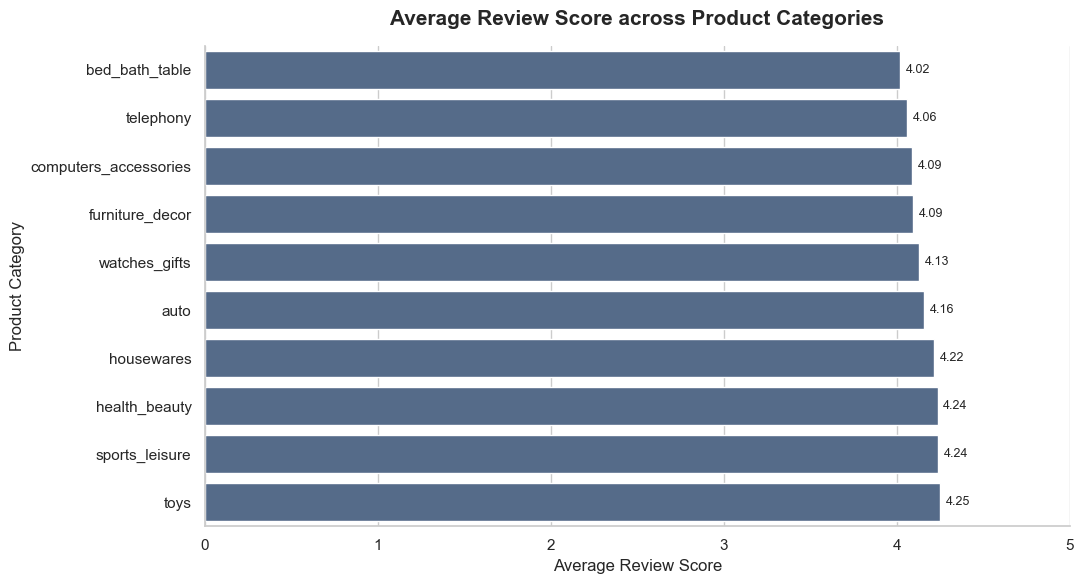

In [41]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=category_review_summary,
    x="average_review_score",
    y="product_category",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Average Review Score across Product Categories",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Average Review Score")
ax.set_ylabel("Product Category")
ax.set_xlim(0, 5)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=4,
        fontsize=9,
    )

sns.despine()
plt.tight_layout()
plt.show()

### Category Review Findings

Average review scores are relatively high across all ten major product categories, ranging from approximately 4.02 to 4.25.

The differences between categories are visible but fairly small in absolute terms. `toys`, `sports_leisure`, and `health_beauty` have the highest average ratings, while `bed_bath_table`, `telephony`, and `computers_accessories` have the lowest.

The maximum gap is only about 0.23 points on a five-point scale. Therefore, even if the differences turn out to be statistically significant, their practical importance may be limited.

A statistical test is needed to determine whether the observed differences are larger than what could be expected from sampling variability.

### Kruskal–Wallis Test

In [42]:
category_groups = [
    group["review_score"].values
    for _, group in category_reviews.groupby(
        "product_category"
    )
]

category_kruskal_result = stats.kruskal(
    *category_groups
)

category_kruskal_statistic = (
    category_kruskal_result.statistic
)

category_kruskal_p_value = (
    category_kruskal_result.pvalue
)

category_kruskal_statistic, category_kruskal_p_value

(np.float64(282.1023359626111), np.float64(1.6227943044776558e-55))

### Effect Size: Epsilon-Squared

In [43]:
category_groups_count = (
    category_reviews["product_category"]
    .nunique()
)

category_observations_count = len(
    category_reviews
)

category_epsilon_squared = (
    category_kruskal_statistic
    - category_groups_count
    + 1
) / (
    category_observations_count
    - category_groups_count
)

category_epsilon_squared

np.float64(0.004555805824619009)

### Statistical Test Summary

In [44]:
category_test_summary = pd.DataFrame(
    {
        "metric": [
            "Kruskal–Wallis statistic",
            "Kruskal–Wallis p-value",
            "Epsilon-squared",
        ],
        "value": [
            category_kruskal_statistic,
            category_kruskal_p_value,
            category_epsilon_squared,
        ],
    }
)

category_test_summary

,metric,value
0,Kruskal–Wallis statistic,282.102
1,Kruskal–Wallis p-value,0.000
2,Epsilon-squared,0.005


### Hypothesis Test Conclusion

The Kruskal–Wallis test produces an effectively zero p-value, so the null hypothesis that review score distributions are identical across the analyzed product categories is rejected.

However, the epsilon-squared effect size is approximately **0.005**, which indicates a negligible practical effect. This means that product category explains only a very small share of the variation in review scores.

Therefore, the category differences are statistically significant mainly because of the large sample size, but they are not large enough to be considered an important standalone driver of customer satisfaction.

From a business perspective, delivery performance, seller quality, product condition, and customer expectations are likely to be more important than category alone.

## 5. Multiple Testing and Effect Sizes

In [45]:
hypothesis_summary = pd.DataFrame(
    {
        "hypothesis": [
            "Delayed orders have lower review scores",
            "Higher-value orders take longer to deliver",
            "Orders with more items have higher freight cost",
            "Review scores differ across product categories",
        ],
        "method": [
            "Welch t-test, Mann–Whitney U",
            "Pearson and Spearman correlation",
            "Spearman correlation, Kruskal–Wallis",
            "Kruskal–Wallis",
        ],
        "p_value": [
            max(
                welch_p_value,
                mann_whitney_p_value,
            ),
            spearman_p_value,
            kruskal_p_value,
            category_kruskal_p_value,
        ],
        "effect_measure": [
            "Cohen's d",
            "Spearman correlation",
            "Epsilon-squared",
            "Epsilon-squared",
        ],
        "effect_value": [
            review_cohens_d,
            spearman_correlation,
            epsilon_squared,
            category_epsilon_squared,
        ],
    }
)

hypothesis_summary

,hypothesis,method,p_value,effect_measure,effect_value
0,Delayed orders have lower review scores,"Welch t-test, Mann–Whitney U",0.000,Cohen's d,-1.446
1,Higher-value orders take longer to deliver,Pearson and Spearman correlation,0.000,Spearman correlation,0.143
2,Orders with more items have higher freight cost,"Spearman correlation, Kruskal–Wallis",0.000,Epsilon-squared,0.145
3,Review scores differ across product categories,Kruskal–Wallis,0.000,Epsilon-squared,0.005


In [46]:
def interpret_effect(
    effect_measure: str,
    effect_value: float,
) -> str:
    absolute_value = abs(effect_value)

    if effect_measure == "Cohen's d":
        if absolute_value < 0.2:
            return "Negligible"
        if absolute_value < 0.5:
            return "Small"
        if absolute_value < 0.8:
            return "Medium"
        return "Large"

    if effect_measure == "Spearman correlation":
        if absolute_value < 0.1:
            return "Negligible"
        if absolute_value < 0.3:
            return "Weak"
        if absolute_value < 0.5:
            return "Moderate"
        return "Strong"

    if effect_measure == "Epsilon-squared":
        if absolute_value < 0.01:
            return "Negligible"
        if absolute_value < 0.06:
            return "Small"
        if absolute_value < 0.14:
            return "Medium"
        return "Large"

    return "Not classified"

In [47]:
hypothesis_summary["effect_interpretation"] = (
    hypothesis_summary.apply(
        lambda row: interpret_effect(
            row["effect_measure"],
            row["effect_value"],
        ),
        axis=1,
    )
)

hypothesis_summary

,hypothesis,method,p_value,effect_measure,effect_value,effect_interpretation
0,Delayed orders have lower review scores,"Welch t-test, Mann–Whitney U",0.000,Cohen's d,-1.446,Large
1,Higher-value orders take longer to deliver,Pearson and Spearman correlation,0.000,Spearman correlation,0.143,Weak
2,Orders with more items have higher freight cost,"Spearman correlation, Kruskal–Wallis",0.000,Epsilon-squared,0.145,Large
3,Review scores differ across product categories,Kruskal–Wallis,0.000,Epsilon-squared,0.005,Negligible


In [48]:
significance_level = 0.05

hypothesis_summary["statistically_significant"] = (
    hypothesis_summary["p_value"]
    < significance_level
)

hypothesis_summary

,hypothesis,method,p_value,effect_measure,effect_value,effect_interpretation,statistically_significant
0,Delayed orders have lower review scores,"Welch t-test, Mann–Whitney U",0.000,Cohen's d,-1.446,Large,True
1,Higher-value orders take longer to deliver,Pearson and Spearman correlation,0.000,Spearman correlation,0.143,Weak,True
2,Orders with more items have higher freight cost,"Spearman correlation, Kruskal–Wallis",0.000,Epsilon-squared,0.145,Large,True
3,Review scores differ across product categories,Kruskal–Wallis,0.000,Epsilon-squared,0.005,Negligible,True


### Overall Statistical Findings

All four hypotheses are statistically significant at the \(0.05\) level. However, the practical importance of the effects differs substantially.

1. **Delivery delays and review scores**

   Delayed orders receive substantially lower review scores. Cohen's \(d=-1.446\) indicates a large effect, so delivery delay is not only statistically significant but also practically important.

2. **Order value and delivery time**

   Higher-value orders tend to take slightly longer to deliver, but the Spearman correlation of \(0.143\) indicates only a weak relationship. Order value alone has limited predictive value for delivery time.

3. **Order size and freight cost**

   Orders with more items have higher freight costs. The epsilon-squared value of \(0.145\) indicates a large effect, making item count an important factor associated with shipping cost.

4. **Product category and review scores**

   Review score distributions differ statistically across product categories, but the epsilon-squared value of \(0.005\) indicates a negligible effect. Product category alone explains very little of the variation in customer satisfaction.

### Business Interpretation

The strongest business-relevant results are related to delivery delays and freight costs.

Reducing delivery delays is likely to produce a meaningful improvement in customer satisfaction. The number of items in an order should also be considered when estimating shipping costs and designing delivery pricing.

By contrast, the associations between order value and delivery time and between product category and review score are statistically significant but comparatively weak. They should not be treated as primary decision factors without considering additional operational variables.

## 6. Key Findings

### Key Takeaways

- Delivery delays have a large negative association with customer review scores.
- Order value has only a weak positive association with delivery time.
- Item count has a meaningful positive association with freight cost.
- Product category differences in review scores are statistically significant but practically negligible.
- Large datasets can produce extremely small p-values even when the effect itself is weak.
- Business decisions should therefore rely on both statistical significance and effect size.

### Limitations

- The analysis is observational and does not establish causal relationships.
- Important variables such as exact delivery distance, carrier, product dimensions, and seller operational quality may confound the observed relationships.
- Multiple comparisons were summarized, but no formal p-value correction was applied because the number of primary hypotheses was small and all p-values were extremely low.

In [49]:
engine.dispose()